<a href="https://colab.research.google.com/github/SebastianD2/Lab_Biosenales/blob/main/Practica4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practica No. 4
####Introducción a los biopotenciales y adquisición de señales ECG y EMG


Nombres:
- Juan Sebastian Daza Bentancourt
- Juan Jose Lopez Cuadros

#5.1

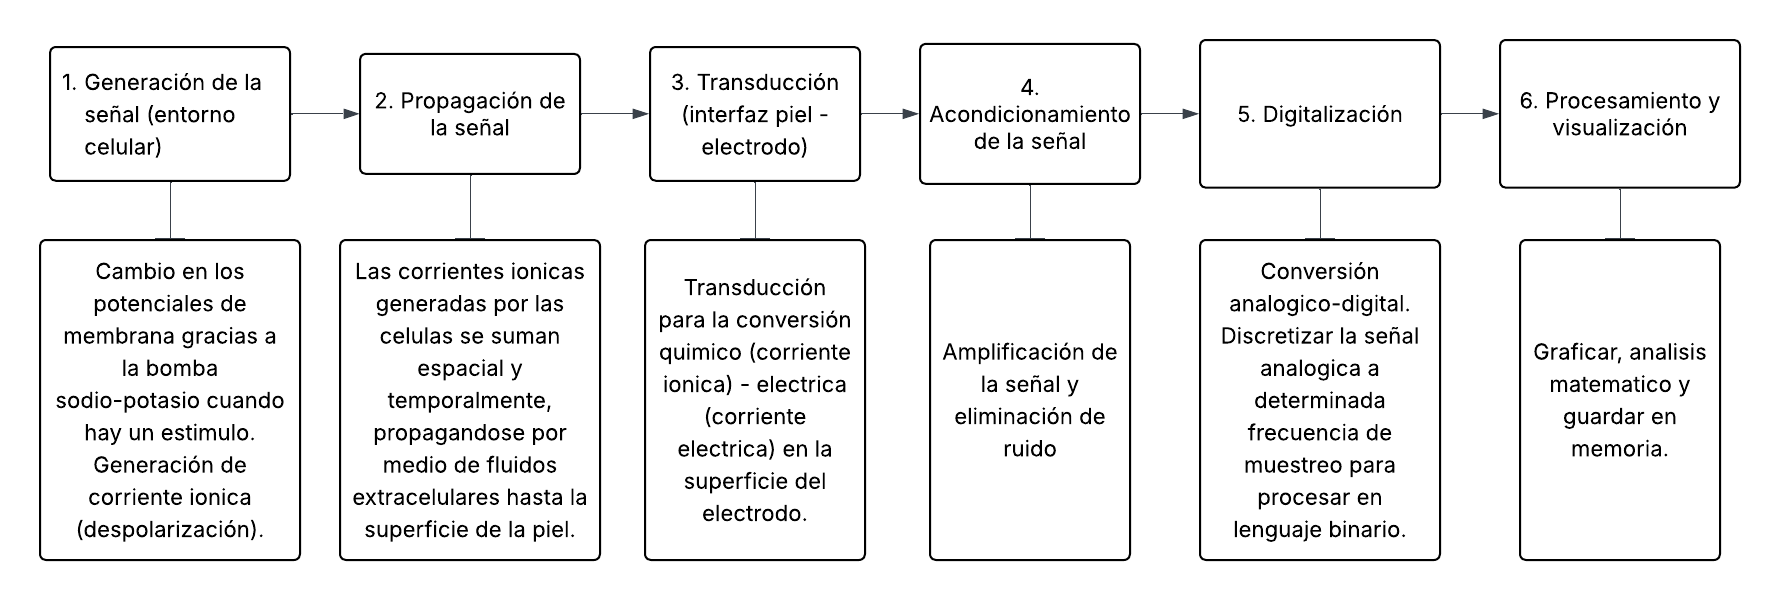

#5.2

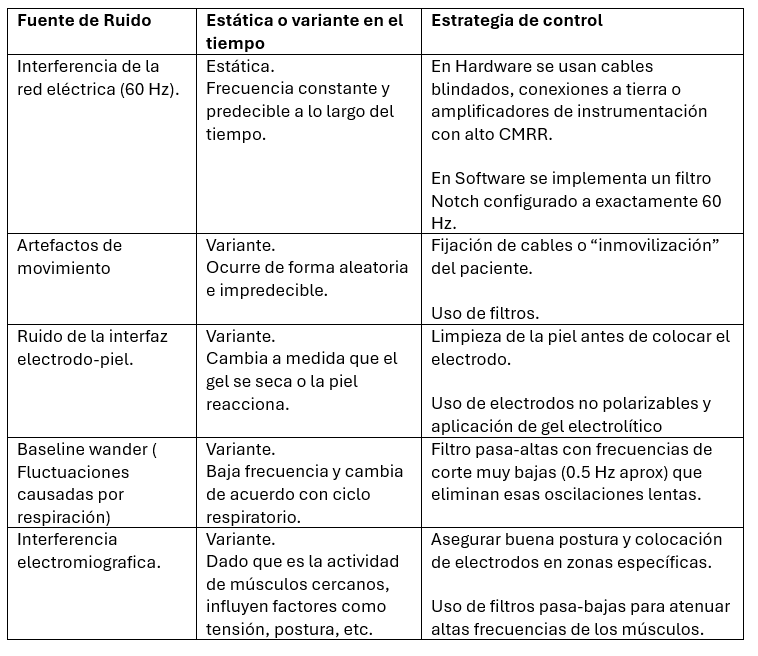

#5.3

###¿Cuál es la problemática asociada al acoplamiento piel-electrodo?
- La impedancia se ve afectada por la presencia de la capa córnea (estrato córneo) de la piel, la cual tiene propiedades dieléctricas que actúan como un condensador. Otros factores pueden ser la humedad de la piel, la limpieza de la zona o presencia de aceites y vello, además, la calidad del gel electrolítico si se llega a utilizar.
###¿Cuáles estrategias se utilizan para mejorarla?
- Limpiar la zona. Normalmente se recomienda limpiar la piel con alcohol para eliminar aceites superficiales.
- Abrasión ligera, consiste en realizar una exfoliación suave de la piel para reducir el espesor de la capa de células muertas (estrato córneo).
- Uso de geles, se aplican geles conductores que faciliten el intercambio iónico entre el cuerpo y el electrodo metálico.
###¿Por qué el acoplamiento piel-electrodo constituye la etapa más crítica en el registro de señales de superficie (sEMG, EEG, ECG)?
- Constituye la etapa más crítica ya qque una alta impedancia de entrada en este punto favorece la captación de ruido electromagnético (como la interferencia de 60 Hz de la red eléctrica) y puede causar una atenuación significativa de la señal biológica, que de por sí es de muy baja amplitud.

# 5.4

In [ ]:
pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 28.7 MB/s eta 0:00:00


In [ ]:
pip install py-ecg-detectors

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.5/554.5 kB 16.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for gatspy: filename=gatspy-0.3-py3-none-any.whl size=43804 sha256=241ca02b4ebba0a3aaa1cbbaee5e27d6443dd25d27dbc96f6b62758e63201b37
  Stored in directory: /root/.cache/pip/wheels/b5/56/88/04643e9be584a6018e10aae5789d98225995da3e89513c3f30
Successfully built gatspy


In [ ]:
pip install hrv-analysis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 9.0 MB/s eta 0:00:00


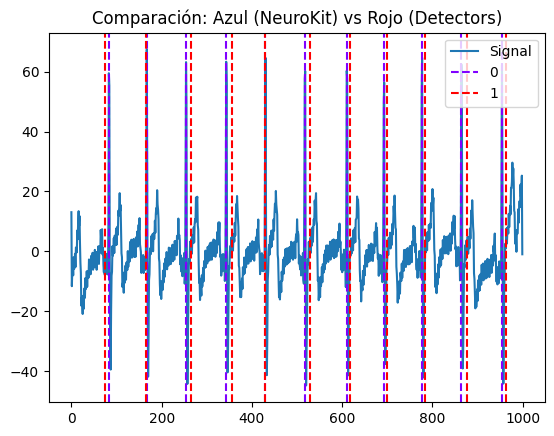


HRV calculado para extraer los parametros

Características con hrvanalysis

 RESULTADOS HRV: DOMINIO DEL TIEMPO 
mean_nni: 871.00
sdnn: 28.46
sdsd: 38.01
nni_50: 1.00
pnni_50: 11.11
nni_20: 5.00
pnni_20: 55.56
rmssd: 38.59
median_nni: 870.00
range_nni: 90.00
cvsd: 0.04
cvnni: 0.03
mean_hr: 68.95
max_hr: 72.29
min_hr: 65.22
std_hr: 2.13


In [ ]:
import pandas as pd
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
from ecgdetectors import Detectors

frecuencia_muestreo = 100
df = pd.read_csv('señalekg.csv')

senal_ecg = df.iloc[:, 0].values
senal_ecg = nk.ecg_clean(senal_ecg, sampling_rate=frecuencia_muestreo)

#1.

#Algoritmo NeuroKit
_, info_nk = nk.ecg_peaks(senal_ecg, sampling_rate=frecuencia_muestreo, method="neurokit")
picos_R_nk = info_nk["ECG_R_Peaks"]

# Algoritmo py-ecg-detectors (Clase Detectors)
detectores = Detectors(frecuencia_muestreo)
picos_R_detectors = detectores.pan_tompkins_detector(senal_ecg)


nk.events_plot([picos_R_nk, picos_R_detectors], senal_ecg)
plt.title("Comparación: Azul (NeuroKit) vs Rojo (Detectors)")
plt.show()


picos_R_finales = picos_R_nk

#2.



# 1. Calculamos la diferencia entre un pico R y el siguiente (esto nos da la distancia en muestras)
intervalos_rr_muestras = np.diff(picos_R_finales)

# 2. Convertimos esa distancia de muestras a milisegundos (ms)
intervalos_rr_ms = (intervalos_rr_muestras / frecuencia_muestreo) * 1000
print("\nHRV calculado para extraer los parametros")

#3.
print("\nCaracterísticas con hrvanalysis")

import astropy.stats
from astropy.timeseries import LombScargle
astropy.stats.LombScargle = LombScargle
from hrvanalysis import get_time_domain_features


# Usamos los intervalos en milisegundos que calculamos en el Punto 2
caracteristicas_tiempo = get_time_domain_features(intervalos_rr_ms)

# Mostrar los resultados finales en la consola
print("\n" + "="*50)
print(" RESULTADOS HRV: DOMINIO DEL TIEMPO ")
print("="*50)
for caracteristica, valor in caracteristicas_tiempo.items():
    print(f"{caracteristica}: {valor:.2f}")
print("="*50)

#5.5
##Aplicaciones Clínicas
###Electrocardiografía (ECG)
1. Detección de Isquemia y Infarto Agudo de Miocardio:
- Registro: Se utiliza un ECG estándar de 12 derivaciones en reposo. Este registro permite observar la actividad eléctrica del corazón desde diferentes ángulos espaciales (planos frontal y horizontal).
- Procesamiento: El análisis se centra en la detección de cambios en el segmento ST (elevación o depresión) y la inversión de la onda T. El procesamiento digital incluye filtros como el Notch para eliminar la interferencia de 60 Hz y filtros de paso alto para corregir el desplazamiento de la línea base causado por la respiración. se hace uso de algoritmos para clasificar automáticamente si el patrón corresponde a una oclusión coronaria.

2. Análisis de la Variabilidad de la Frecuencia Cardíaca (HRV) para Riesgo Autonómico:
- Registro: Registros de larga duración (24 a 48 horas) mediante un monitor Holter.
- Procesamiento: Se requiere una detección extremadamente precisa de los picos R, una vez obtenidos los intervalos R-R, se aplican transformadas de Fourier para analizar los componentes de baja frecuencia y alta frecuencia. Esto permite evaluar el equilibrio entre el sistema nervioso simpático y parasimpático, sirviendo como predictor.

3. Telemetría y Monitorización en Unidades de Cuidados Intensivos (UCI):
- Registro: Monitorización continua mediante 3 o 5 electrodos adheridos al paciente.
- Procesamiento: Procesamiento en tiempo real con algoritmos de detección de umbral. Se configuran alarmas automáticas basadas en la detección de taquicardias ventriculares o asistolia. El procesamiento incluye la supresión de artefactos por movimiento y la detección de pulsos de marcapasos mediante filtros de derivación para evitar que el monitor cuente el pulso del marcapasos como un latido cardíaco.

###Electromiografía (EMG)
1. Estudios de Conducción Nerviosa y Miopatías:
- Registro: EMG de aguja (invasivo). Se inserta un electrodo de aguja directamente en el tejido muscular para registrar los Potenciales de Acción de la unidad motora.
- Procesamiento: El análisis es tanto visual como auditivo. Se procesa la morfología de la unidad motora: amplitud, duración y número de fases (polifasia).

2. Ergonomía y Análisis de Fatiga en Medicina del Trabajo:
- Registro: EMG de superficie sobre músculos específicos
- Procesamiento: Se utiliza el cálculo de la frecuencia mediana y la frecuencia media del espectro de potencia. A medida que el músculo se fatiga, existe un desplazamiento hacia las frecuencias bajas en el espectro debido a la disminución de la velocidad de conducción de las fibras musculares. También se analiza el valor RMS para observar el aumento del reclutamiento de unidades motoras a medida que el músculo pierde eficiencia.

3. Control de Prótesis Robóticas y Biofeedback:
- Registro: Conjunto de electrodos de superficie colocados en el muñón de un paciente amputado.
- Procesamiento: Se aplican técnicas de Extracción de Características (Feature Extraction) en el dominio del tiempo (Muestra de Valor Absoluto Medio, Cruces por Cero) y en el dominio de la frecuencia. Estos datos se ingresan a clasificadores que interpretan el patrón de contracción para traducirlo en movimientos de la prótesis como puede ser abrir/cerrar mano. El procesamiento debe ser de muy baja latencia para que el usuario sienta un control natural.

#5.6
###Conclusiones

- La práctica evidenció que, debido a la naturaleza estocástica del EMG y la baja amplitud del ECG, el uso de filtros analógicos y digitales es indispensable. Sin un filtrado correcto de la banda de 60 Hz y de los ruidos de baja frecuencia (movimiento), los parámetros clínicos como el intervalo R-R o la amplitud RMS del músculo se verían severamente comprometidos.

- Las herramientas computacionales permiten transformar una señal analógica ruidosa en datos diagnósticos cuantitativos. La capacidad de calcular la HRV o el espectro de frecuencia del EMG permite pasar de una observación subjetiva a una evaluación fisiológica precisa del estado autonómico o muscular del paciente.

- Tener éxito en el registro depende mayoritariamente de la preparación de la piel. Una limpieza inadecuada introduce impedancias desiguales en los electrodos, degradando la capacidad del amplificador de instrumentación para rechazar señales de modo común, lo que resalta que la calidad de la adquisición comienza en el contacto físico y no solo en el software.


###Referencias bibliograficas:

- Ramón Surutusa, L. A. (2018). Procesamiento digital de señales biomédicas [Máster en Ingeniería Industrial, Universidad Nacional de Educación a Distancia]. Repositorio UNED. https://www.uned.es/universidad/facultades/dam/jcr:aec2c175-f79e-4478-a0ed-ffec97816b5d/PFM_%20Luis_Alberto_Ramon_Surutusa.pdf
- Masana, M. (2015). Disseny i implementació d'un sistema d'adquisició de senyals biopotencials [Grado en Ingeniería de Tecnologías y Servicios de Telecomunicación, Universitat Politècnica de Catalunya]. UpCommons. https://upcommons.upc.edu/handle/2117/77626
- Webster, J. G. (2009). Medical Instrumentation: Application and Design. John Wiley & Sons.
- Bronzino, J. D. (2000). The Biomedical Engineering HandBook. CRC Press LLC.
- Clifford, G. D., et al. (2006). Advanced Methods and Tools for ECG Data Analysis. Artech House. (Específico para aplicaciones de procesamiento avanzado de ECG).


